In [161]:
import torch
import torch.nn as nn
import torch.utils.data as data
from torch.utils.data import TensorDataset, DataLoader

import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

np.random.seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [162]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [163]:
%cd /content/drive/MyDrive/CursoPINN-CEIA-UBA/20253B/Material didáctico/Modulo6

/content/drive/MyDrive/CursoPINN-CEIA-UBA/20253B/Material didáctico/Modulo6


# PI-DeepONets sin datos rotulados

## Definición de las redes "branch" y "trunk", y de la DeepONet

In [164]:
# Define the Branch Network
class BranchNet(nn.Module):
    def __init__(self, branchNet_params):
        super(BranchNet, self).__init__()
        self.Device = branchNet_params["Device"]
        self.LowerBound = branchNet_params["LowerBound"]
        self.UpperBound = branchNet_params["UpperBound"]
        self.InputDimensions = branchNet_params["InputDimensions"]
        self.OutputDimensions = branchNet_params["OutputDimensions"]
        self.NumberOfNeurons = branchNet_params["NumberOfNeurons"]
        self.NumberOfHiddenLayers = branchNet_params["NumberOfHiddenLayers"]
        self.ActivationFunction = branchNet_params["ActivationFunction"]
        self.InputLayer = nn.Linear(self.InputDimensions, self.NumberOfNeurons)
        self.HiddenLayers = nn.ModuleList(
            [nn.Linear(self.NumberOfNeurons, self.NumberOfNeurons) for _ in range(self.NumberOfHiddenLayers - 1)])
        self.OutputLayer = nn.Linear(self.NumberOfNeurons, self.OutputDimensions)
        self.init_xavier()

    def forward(self, X):
        x = 2 * (X - self.LowerBound[0]) / (self.UpperBound[0] - self.LowerBound[0]) - 1
        output = self.ActivationFunction(self.InputLayer(x))
        for k, l in enumerate(self.HiddenLayers):
            output = self.ActivationFunction(l(output))
        output = self.OutputLayer(output)
        return output

    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                # gain = nn.init.calculate_gain('tanh')
                gain = 1
                torch.nn.init.xavier_uniform_(m.weight, gain=gain)
                torch.nn.init.uniform_(m.bias, 0, 1)

# Define the Trunk Network
class TrunkNet(nn.Module):
    def __init__(self, trunkNet_params):
        super(TrunkNet, self).__init__()
        self.Device = trunkNet_params["Device"]
        self.LowerBound = branchNet_params["LowerBound"]
        self.UpperBound = branchNet_params["UpperBound"]
        self.InputDimensions = trunkNet_params["InputDimensions"]
        self.OutputDimensions = trunkNet_params["OutputDimensions"]
        self.NumberOfNeurons = trunkNet_params["NumberOfNeurons"]
        self.NumberOfHiddenLayers = trunkNet_params["NumberOfHiddenLayers"]
        self.ActivationFunction = trunkNet_params["ActivationFunction"]
        self.InputLayer = nn.Linear(self.InputDimensions, self.NumberOfNeurons)
        self.HiddenLayers = nn.ModuleList(
            [nn.Linear(self.NumberOfNeurons, self.NumberOfNeurons) for _ in range(self.NumberOfHiddenLayers - 1)])
        self.OutputLayer = nn.Linear(self.NumberOfNeurons, self.OutputDimensions)
        self.EnforceIBC = trunkNet_params["EnforceIBC"]
        self.init_xavier()

    def forward(self, X):
        x = 2 * (X - self.LowerBound) / (self.UpperBound - self.LowerBound) - 1
        output = self.ActivationFunction(self.InputLayer(x))
        for k, l in enumerate(self.HiddenLayers):
            output = self.ActivationFunction(l(output))
        output = self.OutputLayer(output)
        return output

    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                # gain = nn.init.calculate_gain('tanh')
                gain = 1
                torch.nn.init.xavier_uniform_(m.weight, gain=gain)
                torch.nn.init.uniform_(m.bias, 0, 1)


# Define the DeepONet
class DeepONet(nn.Module):
    def __init__(self, branch_net, trunk_net):
        super(DeepONet, self).__init__()
        self.branch_net = branch_net
        self.trunk_net = trunk_net


    def interpolate_u0_at(self, u0_batch, x_grid, x_eval):
        """
        x_grid: (N,) - fixed grid where functions are defined
        u0_batch: (B, N) - B batch functions sampled at x_grid
        x_eval: (B, M) - B target evaluation points per function
        Returns:
        u_interp: (B, M) - interpolated values at x_eval for each batch
        """
        B, N = u0_batch.shape
        M = x_eval.shape[0]

        # Ensure x_grid is 1D tensor on the same device
        device = u0_batch.device
        x_grid = x_grid.to(device)

        x_eval = x_eval.contiguous()

        # Searchsorted returns indices such that x_grid[idx-1] <= x_eval < x_grid[idx]
        idx_right = torch.searchsorted(x_grid, x_eval, right=True)
        idx_left = torch.clamp(idx_right - 1, min=0, max=N-2)
        idx_right = torch.clamp(idx_right, max=N-1)

        # Gather x_grid values
        x0 = x_grid[idx_left]     # (B, M)
        x1 = x_grid[idx_right]    # (B, M)

        # Gather y values from u0_batch
        batch_indices = torch.arange(B, device=device).unsqueeze(1)  # (B, 1)
        y0 = u0_batch[batch_indices, idx_left]  # (B, M)
        y1 = u0_batch[batch_indices, idx_right] # (B, M)

        # Linear interpolation
        denom = x1 - x0
        denom[denom == 0] = 1e-8  # avoid divide by zero
        weight = (x_eval - x0) / denom
        u_interp = y0 * (1 - weight) + y1 * weight  # (B, M)
        return u_interp


    def forward(self, branch_input, trunk_input):
        # Get branch and trunk outputs
        branch_output = self.branch_net(branch_input)  # Shape: [batch_size, branch_output_dim]
        trunk_output = self.trunk_net(trunk_input)    # Shape: [batch_size, trunk_output_dim]

        # Combine the outputs (dot product across the last dimension)
        u_pred = torch.sum(branch_output * trunk_output, dim=-1, keepdim=True)

        if self.trunk_net.EnforceIBC:
            u_tilde = u_pred

            u0_left = branch_input[:, 0:1]    # u0(0)
            u0_right = branch_input[:, -1].view(-1, 1)

            # Need to broadcast u0_left/right to match u_tilde
            x_vals = trunk_input[:, 0:1]

            u_pred = (1 - x_vals) * u0_left + x_vals * u0_right + x_vals * (1 - x_vals) * u_tilde

            '''# Need to broadcast u0_left/right to match u_tilde
            x_vals = trunk_input[:, 0:1]

            # IC embedding: (1 - exp(-gamma t)) → 0 at t=0
            t_vals = trunk_input[:, 1:2]
            gamma = .1
            time_mask = 1.0 - torch.exp(-gamma * t_vals)

            u0_x = self.interpolate_u0_at(branch_input, torch.linspace(0., 1., 100), x_vals)
            u_pred = u0_x + x_vals * (1 - x_vals) * time_mask * u_tilde'''

        return u_pred


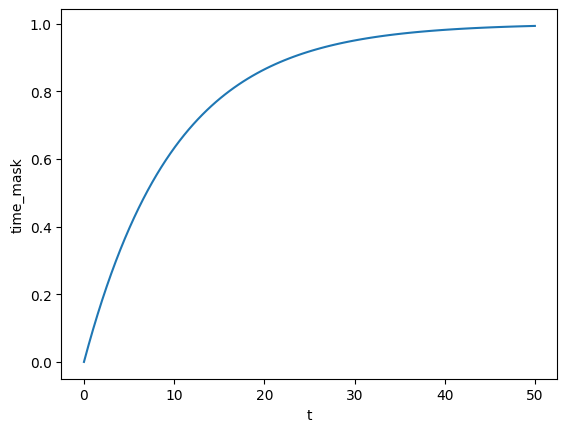

In [165]:
t_vals = torch.linspace(0., 50., 100).to(device)
gamma = 0.1
time_mask = 1.0 - torch.exp(-gamma * t_vals)
plt.plot(t_vals.data.cpu().numpy(), time_mask.data.cpu().numpy())
plt.xlabel('t')
plt.ylabel('time_mask')
plt.show()

## Domain and material properties

In [166]:
xi, xf = 0.0, 1.0
ti, tf = 0.0, 50.0

lb = torch.tensor([xi, ti], dtype=torch.float32).to(device)
ub = torch.tensor([xf, tf], dtype=torch.float32).to(device)

k = 10.
rho = 500.
c = 100.
alpha = k/(rho*c)

## Build datasets

### Source data for branch net

In [167]:
# Download training data
d = np.load("antiderivative_unaligned_train.npz", allow_pickle=True)
ic_train = torch.from_numpy(d["X_train0"]).to(torch.float32).to(device)
x_ic_train = torch.from_numpy(np.linspace(xi, xf, 100)).to(torch.float32).to(device)
x_train = torch.from_numpy(d["X_train1"]).to(torch.float32).to(device)
N_ic_funcs = ic_train.shape[0]

# Download testing data
d = np.load("antiderivative_unaligned_test.npz", allow_pickle=True)
v_test = torch.from_numpy(d["X_test0"]).to(torch.float32).to(device)
x_test = torch.from_numpy(d["X_test1"]).to(torch.float32).to(device)

idx_test = np.random.choice(len(x_test), 100, replace=False)

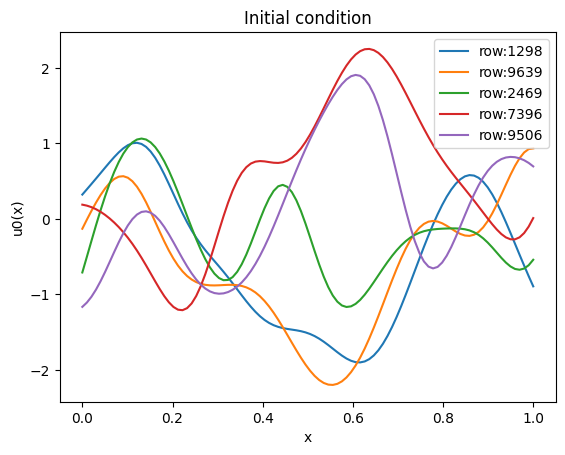

In [168]:
rows = np.random.randint(0, ic_train.shape[0], 5)
for row in rows:
    plt.plot(x_ic_train.data.cpu().numpy(), ic_train[row, :].data.cpu().numpy(), label=f'row:{row}')
plt.xlabel('x')
plt.ylabel('u0(x)')
plt.title('Initial condition')
plt.legend()
plt.show()

## Ground-truth solution (FEM)

In [169]:
nnod = 100
nele = nnod - 1
x_fem = np.linspace(xi, xf, nnod)

nsteps = 100
t_fem = np.linspace(ti, tf, nsteps)
dt = t_fem[1] - t_fem[0]

M = np.zeros((nnod, nnod))
K = np.zeros((nnod, nnod))
for i in range(nele):
    hk = np.abs(x_fem[i+1] - x_fem[i])
    ke = k*np.array([[1/hk, -1/hk], [-1/hk, 1/hk]])
    K[i:i+2, i:i+2] = K[i:i+2, i:i+2] + ke
    me = rho*c*np.array([[hk/3, hk/6], [hk/6, hk/3]])
    M[i:i+2, i:i+2] = M[i:i+2, i:i+2] + me

A = M/dt + K

# Grid for evaluation the exact solution
ms_x, ms_t = np.meshgrid(x_fem, t_fem)
x_test = np.ravel(ms_x).reshape(-1, 1)
t_test = np.ravel(ms_t).reshape(-1, 1)

In [170]:
def get_fem_solution(A, T0, nsteps):
    nnod = A.shape[0]
    TT = np.zeros((nnod, nsteps))
    F = np.zeros((nnod, 1))
    TT[:, 0] = T0
    A[0, :] = 0; A[0, 0] = 1
    A[-1, :] = 0; A[-1, -1] = 1
    for i in range(nsteps-1):
        Ti = TT[:, i:i+1]
        b = np.dot(M/dt, Ti) + F
        b[0] = T0[0]; b[-1] = T0[-1]
        T = np.linalg.solve(A, b)
        TT[:, i+1:i+2] = T

    return TT

In [171]:
# Generate all ground-truth data (very slow)
'''u_train = np.zeros((ic_train.shape[0], nsteps))
for i in range(ic_train.shape[0]):
    T_fem = get_fem_solution(A, ic_train[i, :].data.cpu().numpy(), nsteps)
    u_train[i, :] = T_fem[:, -1]'''

'u_train = np.zeros((ic_train.shape[0], nsteps))\nfor i in range(ic_train.shape[0]):\n    T_fem = get_fem_solution(A, ic_train[i, :].data.cpu().numpy(), nsteps)\n    u_train[i, :] = T_fem[:, -1]'

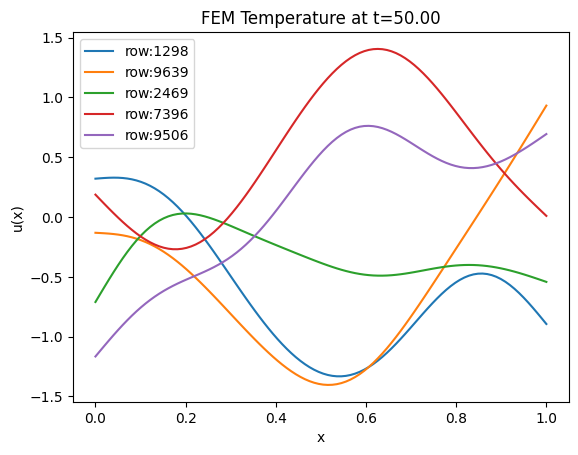

In [172]:
# Temperature data at the final time step
for row in rows:
    T_fem = get_fem_solution(A, ic_train[row, :].data.cpu().numpy(), nsteps)
    plt.plot(x_ic_train.data.cpu().numpy(), T_fem[:, -1], label=f'row:{row}')

plt.xlabel('x')
plt.ylabel('u(x)')
plt.title(f'FEM Temperature at t={tf:.2f}')
plt.legend()
plt.show()

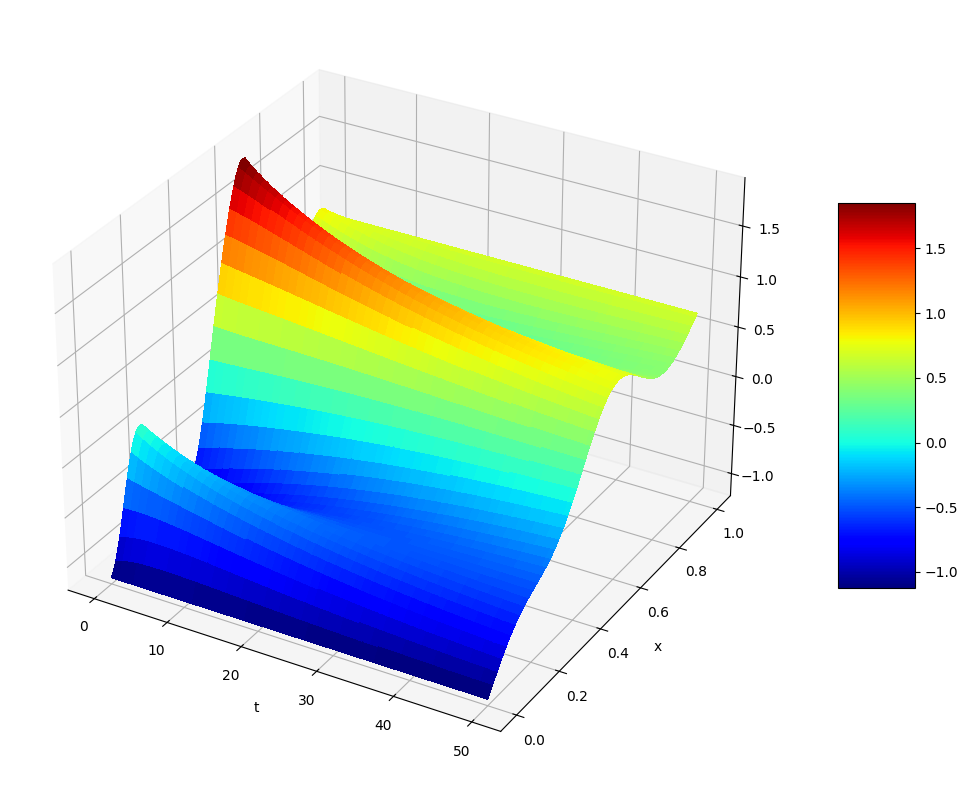

In [173]:
# Plot the exact temperature distribution
T_ex_grid = T_fem.reshape(ms_x.shape)
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection = '3d')
#ax.view_init(elev=20, azim=-90)
surf1 = ax.plot_surface(ms_t, ms_x, T_ex_grid.T, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf1, shrink=0.5, aspect=5)
plt.xlabel('t')
plt.ylabel('x')
plt.show()

### Collocation points

In [174]:
N_cp_pde = 8000
N_cp_bc = 1000
N_cp_ic = 1000

x_coll_pde = np.random.rand(N_cp_pde, 1) * xf
t_coll_pde = np.random.rand(N_cp_pde, 1) * tf
x_t_pde = np.concatenate((x_coll_pde, t_coll_pde), axis=1)
X_train_pde = torch.tensor(x_t_pde, dtype=torch.float32).to(device)
X_train_pde.requires_grad = True

x_coll_bc_l = np.zeros((N_cp_bc//2, 1))
x_coll_bc_r = np.ones((N_cp_bc//2, 1)) * xf
x_coll_bc = np.concatenate((x_coll_bc_l, x_coll_bc_r), axis=0)
t_coll_bc = np.random.rand(N_cp_bc, 1) * tf
x_t_bc = np.concatenate((x_coll_bc, t_coll_bc), axis=1)
X_train_bc = torch.tensor(x_t_bc, dtype=torch.float32).to(device)

x_coll_ic = np.random.rand(N_cp_ic, 1) * xf
t_coll_ic = np.zeros((N_cp_ic, 1))
x_t_ic = np.concatenate((x_coll_ic, t_coll_ic), axis=1)
X_train_ic = torch.tensor(x_t_ic, dtype=torch.float32).to(device)

In [175]:
X_train_full = torch.cat((X_train_pde, X_train_bc), dim=0)

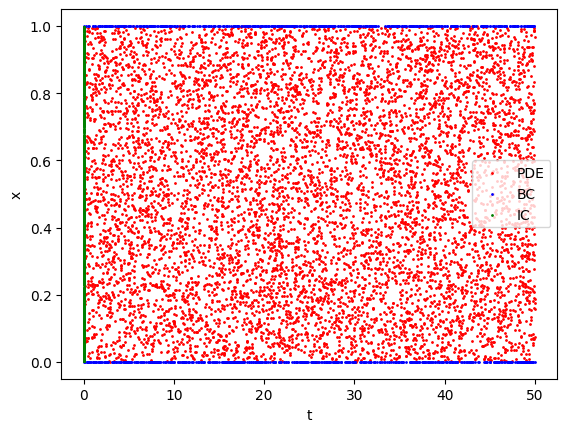

In [176]:
plt.scatter(t_coll_pde, x_coll_pde, s=1, label='PDE', color='r')
plt.scatter(t_coll_bc, x_coll_bc, s=1, label='BC', color='b')
plt.scatter(t_coll_ic, x_coll_ic, s=1, label='IC', color='g')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()
plt.show()

## Initialization

In [177]:
# Initialization parameters
branchNet_params = {
    "Device": device,
    "LowerBound": lb,
    "UpperBound": ub,
    "InputDimensions": 100,
    "OutputDimensions": 100,
    "NumberOfNeurons": 100,
    "NumberOfHiddenLayers": 5,
    "ActivationFunction": nn.GELU()
}

trunkNet_params = {
    "Device": device,
    "LowerBound": lb,
    "UpperBound": ub,
    "InputDimensions": 2,
    "OutputDimensions": 100,
    "NumberOfNeurons": 100,
    "NumberOfHiddenLayers": 5,
    "ActivationFunction": nn.GELU(),
    "EnforceIBC": True
}

## Main loop over epochs

In [178]:
# Build model
branch_net = BranchNet(branchNet_params).to(device)
trunk_net = TrunkNet(trunkNet_params).to(device)
model = DeepONet(branch_net, trunk_net).to(device)

In [179]:
def interpolate_batch(v_train, x_grid, x_train, device):
    N, M = v_train.shape
    dx = x_grid[1] - x_grid[0]  # assuming uniform spacing

    # Clamp x_train to [0, 1]
    x_clamped = torch.clamp(x_train, 0.0, 1.0)

    # Compute the left index of the interpolation interval for each x
    idx = torch.floor(x_clamped / dx).long()  # shape: [N, K]
    idx = torch.clamp(idx, 0, M - 2)  # ensure idx+1 does not go out of bounds

    # Gather left and right y values
    v_left = torch.gather(v_train, 1, idx)           # shape: [N, K]
    v_right = torch.gather(v_train, 1, idx + 1)       # shape: [N, K]

    # Compute weights
    x_left = idx.float() * dx  # [N, K]
    alpha = (x_clamped - x_left) / dx  # fractional distance between grid points

    # Linear interpolation
    v_interp = (1 - alpha) * v_left + alpha * v_right  # [N, K]
    return v_interp


In [180]:
# Training Setup

epochs = 20000
lr = 1e-4
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
train_loss_pde_list = []
train_loss_bc_list = []
train_loss_ic_list = []
enforce_ibc = trunkNet_params["EnforceIBC"]
if enforce_ibc:
    N_cp_pde = N_cp_pde + N_cp_bc #+ N_cp_ic
    X_train_pde = X_train_full

for epoch in range(epochs):

    # Forward pass
    idx_map = torch.randint(0, N_ic_funcs, (N_cp_pde,), device=device)
    ic_input = ic_train[idx_map, :]
    u_pred_pde = model(ic_input, X_train_pde)


    # Compute PDE residuals
    u_pred_pde.requires_grad_(True)
    grads = torch.autograd.grad(u_pred_pde, X_train_pde,
                                grad_outputs=torch.ones_like(u_pred_pde),
                                create_graph=True)[0]
    u_t = grads[:, 1:2]
    u_x = grads[:, 0:1]

    grads2 = torch.autograd.grad(u_x, X_train_pde,
                                grad_outputs=torch.ones_like(u_x),
                                create_graph=True)[0]
    u_xx = grads2[:, 0:1]

    residual_pde = rho*c*u_t - k * u_xx
    loss_pde = torch.mean(residual_pde**2)


    # Compute BC residuals
    idx_map = torch.randint(0, N_ic_funcs, (N_cp_bc,), device=device)
    ic_input = ic_train[idx_map, :]
    u_pred_bc = model.forward(ic_input, X_train_bc)
    u_true_bc_l = ic_input[:N_cp_bc//2, 0].view(-1, 1)
    u_true_bc_r = ic_input[N_cp_bc//2:, -1].view(-1, 1)
    u_true_bc = torch.cat((u_true_bc_l, u_true_bc_r), dim=0)
    loss_bc = torch.mean((u_pred_bc - u_true_bc)**2)


    # Compute IC residuals
    idx_map = torch.randint(0, N_ic_funcs, (N_cp_ic,), device=device)
    ic_input = ic_train[idx_map, :]
    u_pred_ic = model.forward(ic_input, X_train_ic)
    u_true_ic = interpolate_batch(ic_input, torch.linspace(0, 1., ic_input.shape[1], device=device), X_train_ic[:, 0:1], device)
    loss_ic = torch.mean((u_pred_ic - u_true_ic)**2)


    # Compute loss
    if enforce_ibc:
        loss = loss_pde
    else:
        loss = loss_pde + loss_bc + loss_ic

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    # Logs
    train_loss_pde_list.append(loss_pde.item())
    train_loss_bc_list.append(loss_bc.item())
    train_loss_ic_list.append(loss_ic.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}, PDE Loss: {loss_pde.item():.6f}, BC Loss: {loss_bc.item():.6f}, IC Loss: {loss_ic.item():.6f}")

Epoch 1, PDE Loss: 0.089167, BC Loss: 0.000000, IC Loss: 1.157545
Epoch 11, PDE Loss: 0.009104, BC Loss: 0.000000, IC Loss: 1.185773
Epoch 21, PDE Loss: 0.004771, BC Loss: 0.000000, IC Loss: 1.222601
Epoch 31, PDE Loss: 0.001245, BC Loss: 0.000000, IC Loss: 1.189993
Epoch 41, PDE Loss: 0.001215, BC Loss: 0.000000, IC Loss: 1.186443
Epoch 51, PDE Loss: 0.000453, BC Loss: 0.000000, IC Loss: 1.166944
Epoch 61, PDE Loss: 0.000335, BC Loss: 0.000000, IC Loss: 1.112604
Epoch 71, PDE Loss: 0.000233, BC Loss: 0.000000, IC Loss: 1.128243
Epoch 81, PDE Loss: 0.000187, BC Loss: 0.000000, IC Loss: 1.116284
Epoch 91, PDE Loss: 0.000152, BC Loss: 0.000000, IC Loss: 1.217355
Epoch 101, PDE Loss: 0.000127, BC Loss: 0.000000, IC Loss: 1.076443
Epoch 111, PDE Loss: 0.000108, BC Loss: 0.000000, IC Loss: 1.194029
Epoch 121, PDE Loss: 0.000100, BC Loss: 0.000000, IC Loss: 1.323528
Epoch 131, PDE Loss: 0.000091, BC Loss: 0.000000, IC Loss: 1.213768
Epoch 141, PDE Loss: 0.000085, BC Loss: 0.000000, IC Loss: 

KeyboardInterrupt: 

## Plotting

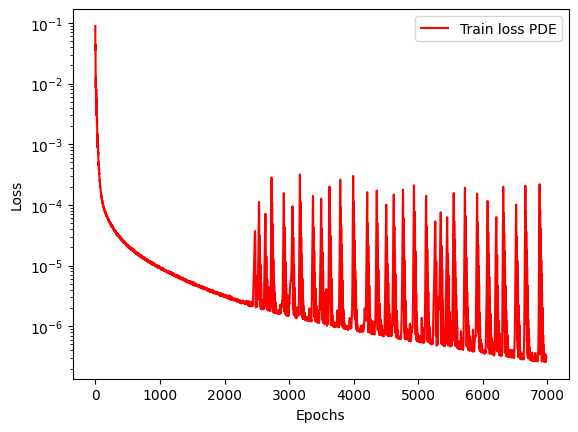

In [181]:
# Losses
trained_epochs = len(train_loss_pde_list)
plt.semilogy(np.arange(trained_epochs), train_loss_pde_list, color='r', label='Train loss PDE')
if enforce_ibc is False:
    plt.semilogy(np.arange(trained_epochs), train_loss_bc_list, color='b', label='Train loss BC')
    plt.semilogy(np.arange(trained_epochs), train_loss_ic_list, color='g', label='Train loss IC')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

## Predictions

In [182]:
idx_trial = np.random.choice(len(x_test), 1, replace=False)
u0_trial = v_test[idx_trial, :].flatten()

In [186]:
x_trial = torch.linspace(0, 1, 100).to(device)
t_eval = 1. # Time at which we want to evaluate the temperature
t_trial = torch.full((100, 1), t_eval).to(device)
X_trial = torch.cat((x_trial.view(-1, 1), t_trial), dim=1)
v_trial = (u0_trial.reshape(1, 100)).to(device)

u_pred = model(v_trial.repeat(100, 1), X_trial)

In [187]:
T_fem_trial = get_fem_solution(A, u0_trial.data.cpu().numpy(), nsteps)
idx_upper = np.searchsorted(t_fem, t_eval)
idx_lower = idx_upper - 1
T_fem_eval = T_fem_trial[:, idx_lower] + (T_fem_trial[:, idx_upper] - T_fem_trial[:, idx_lower])/(t_fem[idx_upper] - t_fem[idx_lower]) * (t_eval - t_fem[idx_lower])

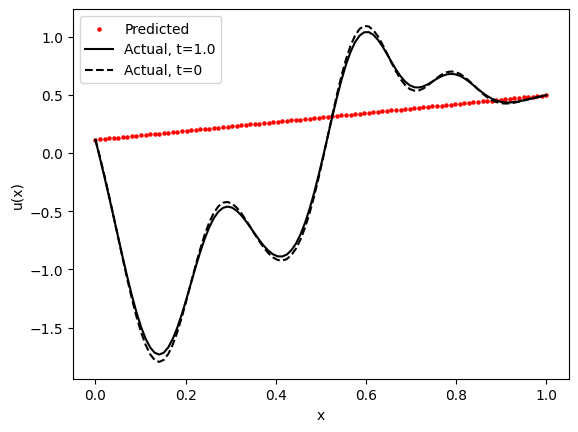

In [188]:
plt.scatter(np.linspace(0, 1, 100), u_pred.cpu().detach().numpy(), s=5, color='r', label='Predicted')
plt.plot(np.linspace(0, 1, 100), T_fem_eval, color='k', label=f'Actual, t={t_eval}')
plt.plot(np.linspace(0, 1, 100), T_fem_trial[:, 0], linestyle='--', color='k', label='Actual, t=0')
plt.legend()
plt.xlabel('x')
plt.ylabel('u(x)')
plt.show()